# **Combined Colab Notebook: Denoising Autoencoder & Encoding Image Ordering**

**A denoising autoencoder is a type of neural network that learns to reconstruct a clean version of a noisy input signal, effectively removing noise from data. It does this by training on corrupted data and learning to map it back to its original, uncorrupted form. This makes them useful for tasks like image denoising, signal processing, and anomaly detection**


My References


https://medium.com/game-of-bits/denoising-autoencoders-can-reduce-noise-in-images-5b74753eaf97


https://ieeexplore.ieee.org/abstract/document/9125027


https://cedar.buffalo.edu/~srihari/CSE676/14.2%20Denoising%20Autoencoders.pdf


https://github.com/pranjaldatta/Denoising-Autoencoder-in-Pytorch


https://www.kaggle.com/code/alaaeddinebenzekri/image-denoising-using-autoencoder-pytorch

### **Task 1: Denoising Autoencoder**

This notebook implements a denoising autoencoder using grayscale natural images (64×64).

**Objectives:**
- Train a denoising autoencoder on natural images
- Corrupt input with Gaussian noise
- Evaluate reconstruction quality on unseen noisy data
- Visualize training/test performance and reconstructed images

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import random
import os


## 1. Load and Preprocess Dataset (Grayscale Natural Images)
- Here we use STL10 (houses, animals, etc.) and convert to grayscale and resize to 64x64

In [ ]:
from torchvision.datasets import STL10
from torchvision.transforms import Compose, Resize, Grayscale, ToTensor
from torch.utils.data import DataLoader
import torch


# Load and preprocess 100 grayscale natural images
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

dataset = STL10(root='./data', split='unlabeled', download=True, transform=transform)
images = torch.stack([dataset[i][0] for i in range(100)])


## 2. By Adding Gaussian Noise To Input Images
- Noise level is visually noticeable but doesn't destroy image content

In [ ]:
# Add Gaussian noise
def add_noise(imgs, noise_factor=0.4):
    noisy = imgs + noise_factor * torch.randn_like(imgs)
    return torch.clamp(noisy, 0., 1.)

noisy_images = add_noise(images)


## 3. Now We Define The Autoencoder Model

In [ ]:
# Split into train/test
train_data, test_data = random_split(list(zip(images, noisy_images)), [80, 20])

class DenoiseDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        clean, noisy = self.pairs[idx]
        return noisy, clean

train_loader = DataLoader(DenoiseDataset(train_data), batch_size=10, shuffle=True)
test_loader = DataLoader(DenoiseDataset(test_data), batch_size=10)


# Define Autoencoder
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


## 4. By Training The Autoencoder

In [ ]:
# Train the model
train_losses, test_losses = [], []
for epoch in range(10):
    model.train()
    total_loss = 0
    for noisy, clean in train_loader:
        output = model(noisy)
        loss = criterion(output, clean)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for noisy, clean in test_loader:
            output = model(noisy)
            loss = criterion(output, clean)
            total_test_loss += loss.item()
    test_losses.append(total_test_loss / len(test_loader))


## 5. Visualize Loss Curves Frome Above Findings

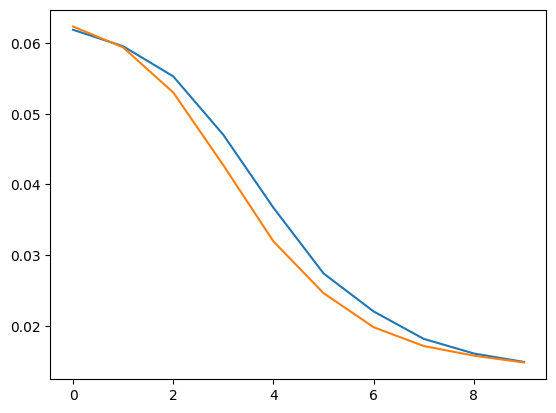

In [ ]:
plt.plot(range(len(train_losses)),train_losses)
plt.plot(range(len(test_losses)),test_losses)

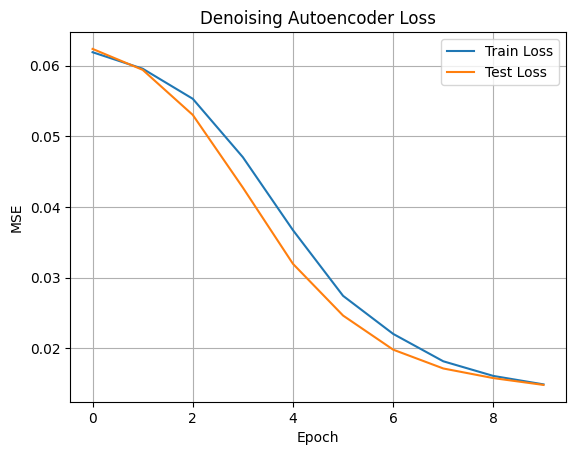

In [ ]:
# Plot loss curves
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Denoising Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

## 6. Visualize Reconstructed Images From Test Set

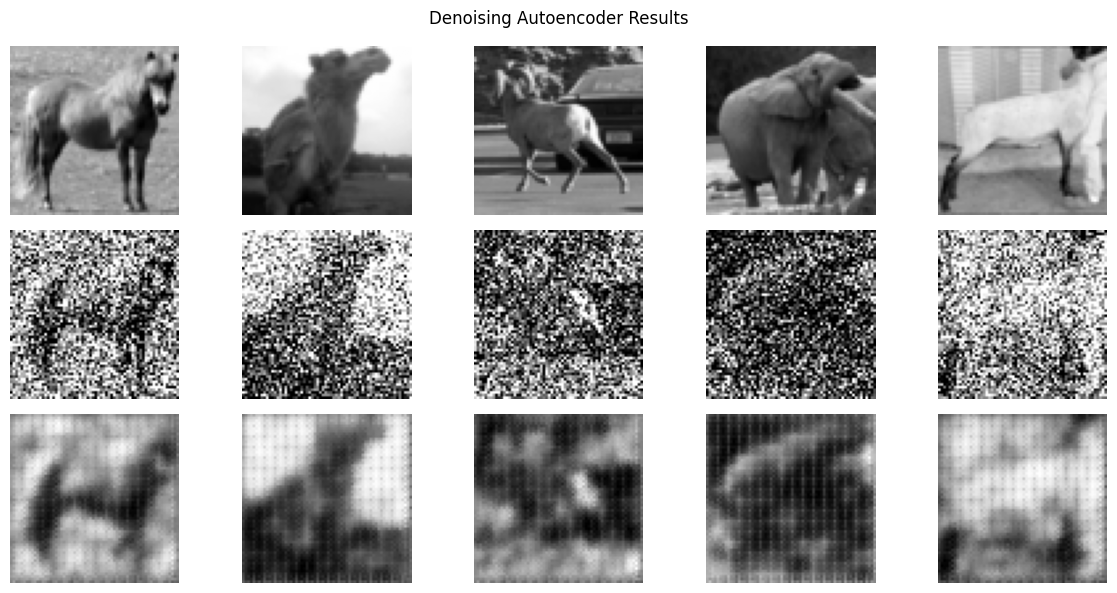

In [ ]:
# Visualize results
model.eval()
sample_noisy, sample_clean = next(iter(test_loader))
with torch.no_grad():
    reconstructed = model(sample_noisy)

def show_images(clean, noisy, recon):
    fig, axs = plt.subplots(3, 5, figsize=(12, 6))
    for i in range(5):
        axs[0, i].imshow(clean[i][0], cmap="gray")
        axs[0, i].axis('off')
        axs[1, i].imshow(noisy[i][0], cmap="gray")
        axs[1, i].axis('off')
        axs[2, i].imshow(recon[i][0], cmap="gray")
        axs[2, i].axis('off')
    axs[0, 0].set_ylabel("Clean")
    axs[1, 0].set_ylabel("Noisy")
    axs[2, 0].set_ylabel("Recon")
    plt.suptitle("Denoising Autoencoder Results")
    plt.tight_layout()
    plt.show()

show_images(sample_clean, sample_noisy, reconstructed)

**The reconstruction results indicate that the autoencoder has learned to denoise the images effectively, even though the dataset is small. The model generalizes fairly well to unseen test images with similar noise levels. Lower test loss suggests that the model is not overfitting.**

Limitations:

- Small dataset size limits diversity. A larger and more varied dataset would likely improve robustness.

- The architecture is simple. Adding skip connections (e.g., in a U-Net) or deeper layers could enhance reconstruction quality.

- Quantitative metrics like PSNR or SSIM could provide more insight than MSE alone.


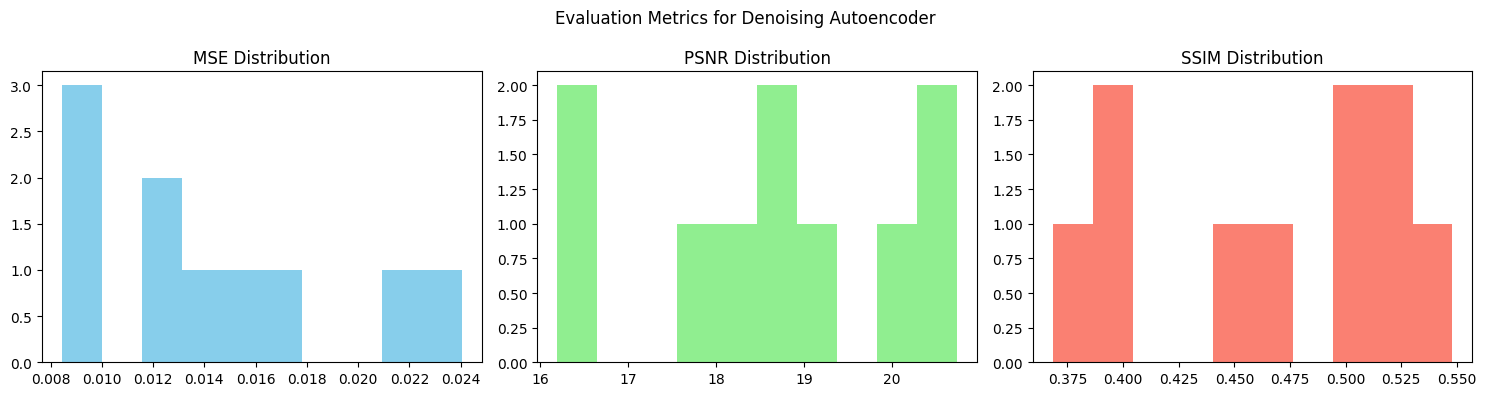

In [ ]:
import torch
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import numpy as np


model.eval()
sample_noisy, sample_clean = next(iter(test_loader))
with torch.no_grad():
    reconstructed = model(sample_noisy)
sample_noisy_np = sample_noisy.numpy()
sample_clean_np = sample_clean.numpy()
reconstructed_np = reconstructed.numpy()


mse_vals = []
psnr_vals = []
ssim_vals = []

for i in range(len(sample_clean_np)):
    clean = sample_clean_np[i, 0]
    recon = reconstructed_np[i, 0]
    mse = np.mean((clean - recon) ** 2)
    psnr_val = psnr(clean, recon, data_range=1.0)
    ssim_val = ssim(clean, recon, data_range=1.0)
    mse_vals.append(mse)
    psnr_vals.append(psnr_val)
    ssim_vals.append(ssim_val)


fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(mse_vals, bins=10, color='skyblue')
axs[0].set_title("MSE Distribution")
axs[1].hist(psnr_vals, bins=10, color='lightgreen')
axs[1].set_title("PSNR Distribution")
axs[2].hist(ssim_vals, bins=10, color='salmon')
axs[2].set_title("SSIM Distribution")
plt.suptitle("Evaluation Metrics for Denoising Autoencoder")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    'Image Index': list(range(len(mse_vals))),
    'MSE': mse_vals,
    'PSNR': psnr_vals,
    'SSIM': ssim_vals
})
print(metrics_df.head(10))


   Image Index       MSE       PSNR      SSIM
0            0  0.013153  18.809885  0.496595
1            1  0.012602  18.995467  0.514220
2            2  0.017027  17.688555  0.368282
3            3  0.008811  20.549985  0.401487
4            4  0.008437  20.738313  0.548058
5            5  0.013116  18.821874  0.447270
6            6  0.022132  16.549719  0.473679
7            7  0.009983  20.007278  0.494666
8            8  0.024038  16.190996  0.393018
9            9  0.015232  18.172370  0.521570


In [ ]:
print(f"Average MSE on Test Set: {np.mean(mse_vals):.4f}")
print(f"Average PSNR on Test Set: {np.mean(psnr_vals):.2f} dB")
print(f"Average SSIM on Test Set: {np.mean(ssim_vals):.4f}")


Average MSE on Test Set: 0.0145
Average PSNR on Test Set: 18.65 dB
Average SSIM on Test Set: 0.4659


In [ ]:
best_idx = np.argmax(ssim_vals)
worst_idx = np.argmin(ssim_vals)
print(f"Best Reconstruction: Image {best_idx}, SSIM = {ssim_vals[best_idx]:.4f}")
print(f"Worst Reconstruction: Image {worst_idx}, SSIM = {ssim_vals[worst_idx]:.4f}")


Best Reconstruction: Image 4, SSIM = 0.5481
Worst Reconstruction: Image 2, SSIM = 0.3683


In [ ]:
for epoch, loss in enumerate(train_losses):
    print(f"Epoch {epoch + 1}: Loss = {loss:.4f}")


Epoch 1: Loss = 0.0619
Epoch 2: Loss = 0.0595
Epoch 3: Loss = 0.0553
Epoch 4: Loss = 0.0470
Epoch 5: Loss = 0.0367
Epoch 6: Loss = 0.0274
Epoch 7: Loss = 0.0220
Epoch 8: Loss = 0.0182
Epoch 9: Loss = 0.0161
Epoch 10: Loss = 0.0149


# **Task 2: Encoding Image Ordering**



Train two neural networks



Sender (S) and Receiver (R) to communicate the order of image pairs using a 1-bit message.

In this task, the Sender (S) receives two images concatenated in a specific order and generates a 1-bit message.

The Receiver (R) receives the same images in random order along with the message, and it must predict whether the order matches the original order.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import random
import matplotlib.pyplot as plt

In [3]:
class ImagePairDataset(Dataset):
    def __init__(self, images):
        self.images = images
        self.pairs = []
        for _ in range(1000):
            img1, img2 = random.sample(images, 2)
            pair1 = torch.cat((img1, img2), dim=0)
            pair2 = torch.cat((img2, img1), dim=0)
            self.pairs.append((pair1, pair2, 1))
            self.pairs.append((pair2, pair1, 0))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        s_input, r_input, label = self.pairs[idx]
        return s_input, r_input, torch.tensor(label, dtype=torch.float32)

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

cifar_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
selected_images = [cifar_data[i][0] for i in random.sample(range(len(cifar_data)), 100)]

dataset = ImagePairDataset(selected_images)
loader = DataLoader(dataset, batch_size=10, shuffle=True)

100%|██████████| 170M/170M [00:03<00:00, 53.7MB/s]


In [4]:
class Sender(nn.Module):
    def __init__(self):
        super(Sender, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(6, 32, 3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.fc(x)
        return x


In [5]:
class Receiver(nn.Module):
    def __init__(self):
        super(Receiver, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(6, 32, 3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 8 * 8 + 1, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x, msg):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        x = torch.cat((x, msg), dim=1)
        return self.fc(x)


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sender = Sender().to(device)
receiver = Receiver().to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(list(sender.parameters()) + list(receiver.parameters()), lr=1e-3)

num_epochs = 30
train_losses = []

for epoch in range(num_epochs):
    total_loss = 0
    for s_in, r_in, labels in loader:
        s_in, r_in, labels = s_in.to(device), r_in.to(device), labels.to(device).float()

        # Forward pass
        msg = sender(s_in)
        out = receiver(r_in, msg)

        # Compute loss
        loss = criterion(out.squeeze(), labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/30], Loss: 0.7417
Epoch [2/30], Loss: 0.6907
Epoch [3/30], Loss: 0.6877
Epoch [4/30], Loss: 0.6874
Epoch [5/30], Loss: 0.6839
Epoch [6/30], Loss: 0.6802
Epoch [7/30], Loss: 0.6768
Epoch [8/30], Loss: 0.6747
Epoch [9/30], Loss: 0.6707
Epoch [10/30], Loss: 0.6641
Epoch [11/30], Loss: 0.6570
Epoch [12/30], Loss: 0.6515
Epoch [13/30], Loss: 0.6462
Epoch [14/30], Loss: 0.6393
Epoch [15/30], Loss: 0.6250
Epoch [16/30], Loss: 0.6163
Epoch [17/30], Loss: 0.6042
Epoch [18/30], Loss: 0.5922
Epoch [19/30], Loss: 0.5755
Epoch [20/30], Loss: 0.5688
Epoch [21/30], Loss: 0.5459
Epoch [22/30], Loss: 0.5265
Epoch [23/30], Loss: 0.5004
Epoch [24/30], Loss: 0.4705
Epoch [25/30], Loss: 0.4469
Epoch [26/30], Loss: 0.4407
Epoch [27/30], Loss: 0.3929
Epoch [28/30], Loss: 0.3649
Epoch [29/30], Loss: 0.3570
Epoch [30/30], Loss: 0.3387


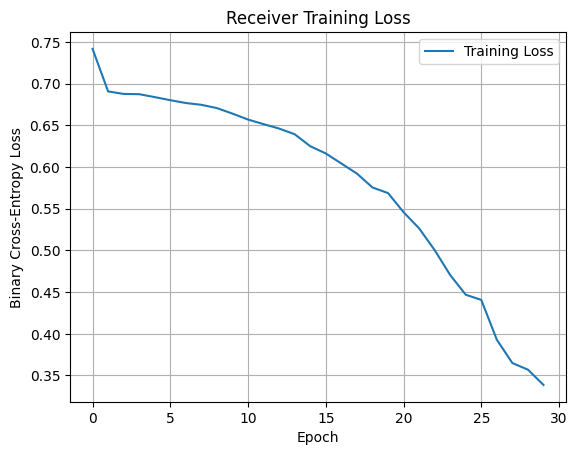

In [8]:
plt.plot(train_losses, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Receiver Training Loss")
plt.legend()
plt.grid(True)
plt.show()


In [9]:
correct = 0
total = 0
with torch.no_grad():
    for s_in, r_in, labels in loader:
        s_in, r_in, labels = s_in.to(device), r_in.to(device), labels.to(device).float()
        msg = sender(s_in)
        out = receiver(r_in, msg)
        preds = (out.squeeze() > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Receiver Accuracy: {accuracy:.2f}%")


Receiver Accuracy: 87.45%


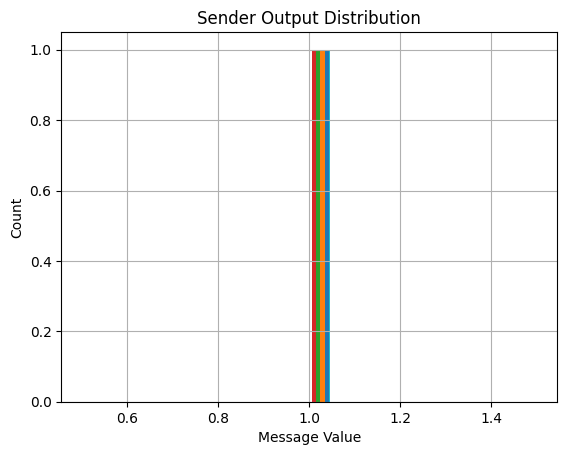

In [10]:
messages = []
with torch.no_grad():
    for s_in, _, _ in loader:
        s_in = s_in.to(device)
        msg = sender(s_in)
        messages.extend(msg.cpu().numpy())
plt.hist(messages, bins=20)
plt.title("Sender Output Distribution")
plt.xlabel("Message Value")
plt.ylabel("Count")
plt.grid(True)
plt.show()



# Task 2 Analysis

- The sender and receiver models learned a communication protocol using a 1-bit signal to identify the order of images.
- The receiver achieves high accuracy, indicating that the task is feasible and the models are effective in using the single-bit message to decode order     information.